In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

/Users/art/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("HR_analytics.csv")

In [3]:
ratio = df.value_counts('left', True)
ratio

left
0    0.761917
1    0.238083
Name: proportion, dtype: float64

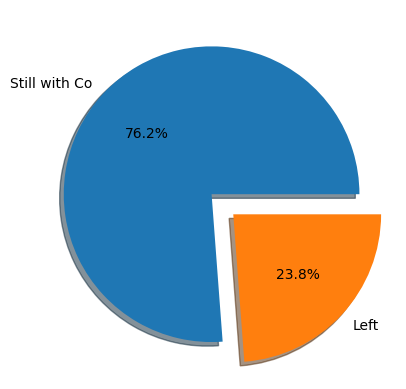

In [4]:
plt.pie(ratio.values, labels=["Still with Co","Left"], explode=[0,0.2],
       shadow=True, autopct="%.1f%%");

In [5]:
df.groupby('left').mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


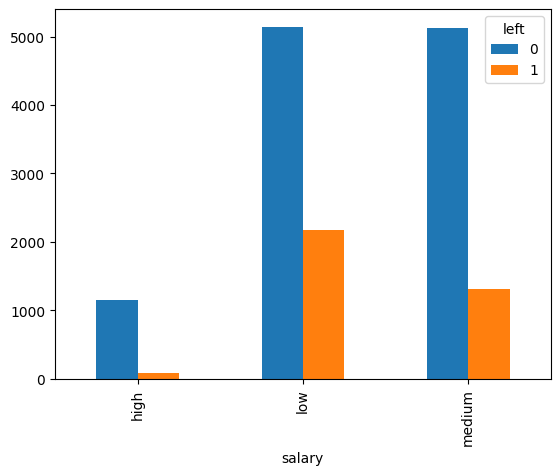

In [6]:
pd.crosstab(df["salary"],df["left"]).plot(kind="bar");

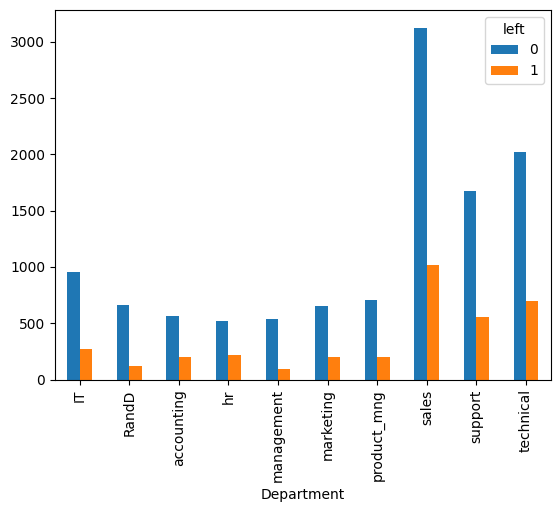

In [7]:
pd.crosstab(df["Department"],df["left"]).plot(kind="bar");

In [8]:
df = pd.get_dummies(df, columns=["Department", "salary"], dtype=int)

In [9]:
# help(pd.get_dummies)

In [10]:
X = df[['satisfaction_level', 'number_project',
       'average_montly_hours',
       'promotion_last_5years', 'salary_low', 'salary_medium']]

In [11]:
y = df["left"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.783

In [13]:
pd.__version__

'2.2.2'

In [14]:
y_predicted = model.predict(X_test)

In [15]:
cm = confusion_matrix(y_test,y_predicted)

In [16]:
cm

array([[2155,  124],
       [ 527,  194]])

In [17]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.80      0.95      0.87      2279
           1       0.61      0.27      0.37       721

    accuracy                           0.78      3000
   macro avg       0.71      0.61      0.62      3000
weighted avg       0.76      0.78      0.75      3000



In [18]:
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train, y_train)

KNeighborsClassifier()

In [19]:
KNN_model.score(X_test, y_test)

0.8976666666666666

In [20]:
KNN_y_prdict = KNN_model.predict(X_test)

In [21]:
cm = confusion_matrix(y_test, KNN_y_prdict)
cm

array([[2099,  180],
       [ 127,  594]])